In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from collections import Counter
from tensorflow.keras.datasets import cifar10, cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

# Loading datasets 

In [2]:
x_train = np.load("x_train.npy")
y_train = np.load("y_train.npy")

x_validation = np.load("x_validation.npy")
y_validation = np.load("y_validation.npy")

x_test = np.load("x_test.npy")
y_test = np.load("y_test.npy")

## Verifying the datasets

In [3]:
num_classes = 24

y_test = to_categorical(
    y_test,
    num_classes=num_classes
)

print("Test labels after encoding:", y_test.shape)

Test labels after encoding: (9100, 24)


In [4]:
np.save("y_test.npy", y_test)

In [5]:
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("\nValidation images:", x_validation.shape)
print("Validation labels:", y_validation.shape)

print("\nTest images:", x_test.shape)
print("Test labels:", y_test.shape)

print("\nTraining pixel range:")
print("Min:", x_train.min(), "Max:", x_train.max())

Training images: (36400, 32, 32, 3)
Training labels: (36400, 24)

Validation images: (9100, 32, 32, 3)
Validation labels: (9100, 24)

Test images: (9100, 32, 32, 3)
Test labels: (9100, 24)

Training pixel range:
Min: 0.0 Max: 1.0


# Final classes

In [6]:
final_classes = [
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "horse",
    "truck",
    "cattle",
    "fox",
    "baby",
    "boy",
    "girl",
    "man",
    "woman",
    "rabbit",
    "squirrel",
    "bicycle",
    "bus",
    "motorcycle",
    "pickup_truck",
    "train",
    "lawn_mower",
    "tractor",
    "trees"
]
num_classes = len(final_classes)

print("\nNumber of classes:", num_classes)


Number of classes: 24


# Building baseline CNN

In [7]:
baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(24, activation='softmax')
])

c:\Users\eljes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,616 (744.59 KB)

 Trainable params: 190,616 (744.59 KB)

 Non-trainable params: 0 (0.00 B)

# Training Model

In [10]:
history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_validation, y_validation),
    verbose=1,
)

Epoch 1/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3293 - loss: 2.1502 - val_accuracy: 0.4092 - val_loss: 1.8936
Epoch 2/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4635 - loss: 1.7279 - val_accuracy: 0.4821 - val_loss: 1.6825
Epoch 3/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5155 - loss: 1.5616 - val_accuracy: 0.5137 - val_loss: 1.6042
Epoch 4/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5506 - loss: 1.4409 - val_accuracy: 0.5492 - val_loss: 1.4718
Epoch 5/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5796 - loss: 1.3515 - val_accuracy: 0.5710 - val_loss: 1.4118
Epoch 6/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6036 - loss: 1.2708 - val_accuracy: 0.5831 - val_loss: 1.3666
Epoch 7/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6244 - loss: 1.1968 - val_accuracy: 0.5593 - val_loss: 1.4258
Epoch 8/15
569/569 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6414 - loss: 1.1331 - val_accur

# Plotting training results

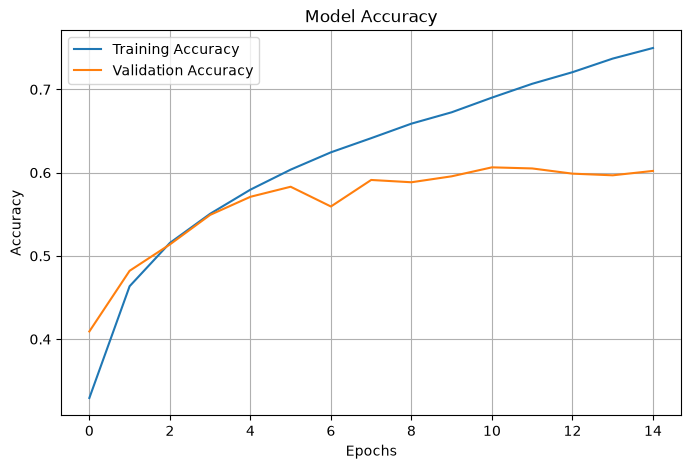

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')

plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.legend()
plt.grid(True)
plt.show()

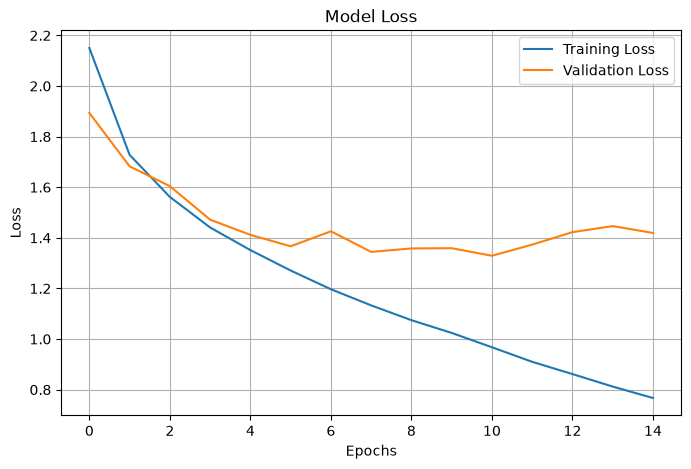

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history['loss'], label='Training Loss')

plt.plot(history_baseline.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.legend()
plt.grid(True)
plt.show()

# Evaluating test set

In [13]:
test_loss, test_accuracy = baseline_model.evaluate(x_test, y_test, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6110 - loss: 1.3584
Test Loss: 1.3584
Test Accuracy: 0.6110


In [14]:
final_train_accuracy = history_baseline.history['accuracy'][-1]
final_validation_accuracy = history_baseline.history['val_accuracy'][-1]

final_train_loss = history_baseline.history['loss'][-1]
final_validation_loss = history_baseline.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_validation_accuracy:.4f}")

print(f"\nFinal Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_validation_loss:.4f}")

print(f"\nAccuracy gap:"
      f" {final_train_accuracy - final_validation_accuracy:.4f}")
print(f"Loss gap:"
      f" {final_train_loss - final_validation_loss:.4f}")

Final Training Accuracy: 0.7498
Final Validation Accuracy: 0.6021

Final Training Loss: 0.7670
Final Validation Loss: 1.4192

Accuracy gap: 0.1477
Loss gap: -0.6522


In [15]:
predictions = baseline_model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=final_classes))

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:
              precision    recall  f1-score   support

  automobile       0.77      0.84      0.80      1000
        bird       0.56      0.63      0.60      1000
         cat       0.50      0.47      0.49      1000
        deer       0.62      0.65      0.64      1000
         dog       0.53      0.64      0.58      1000
       horse       0.71      0.72      0.71      1000
       truck       0.71      0.78      0.74      1000
      cattle       0.15      0.07      0.09       100
         fox       0.44      0.21      0.28       100
        baby       0.30      0.29      0.30       100
         boy       0.30      0.30      0.30       100
        girl       0.28      0.25      0.27       100
         man       0.24      0.21      0.23       100
       woman       0.28      0.14      0.19       100
      rabbit       0.21      0.05      0.08       100
    squirrel       0.31      0.08      0.13       100
     bicycle    

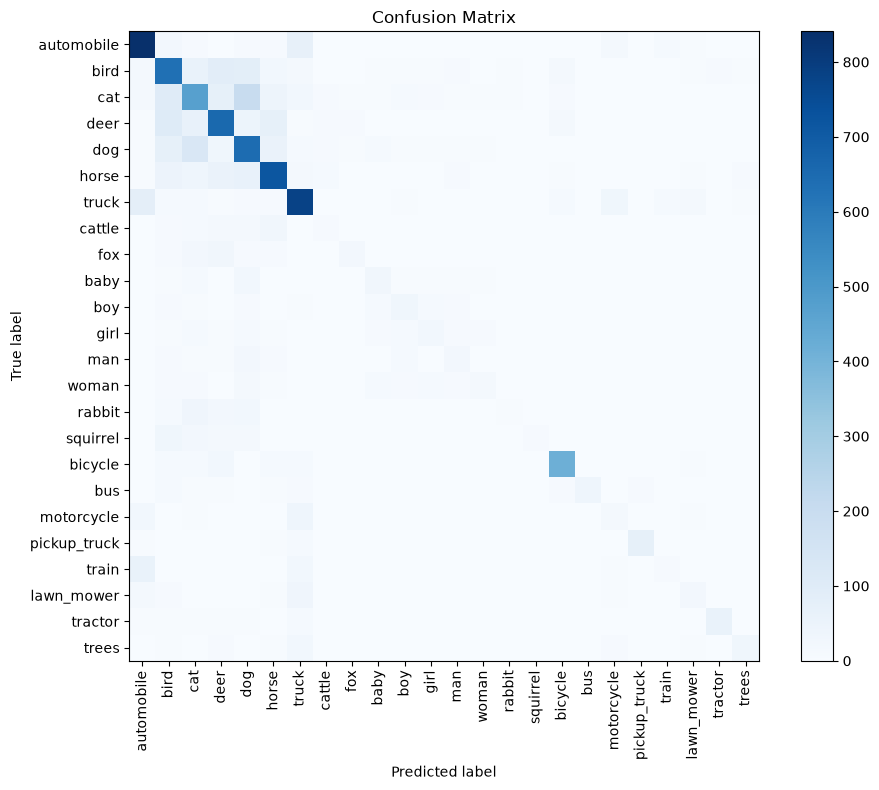

In [16]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 8))

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(num_classes), final_classes, rotation=90)
plt.yticks(np.arange(num_classes), final_classes)

plt.ylabel('True label')
plt.xlabel('Predicted label')

plt.tight_layout()
plt.show()

In [17]:
baseline_model.save("baseline_cnn.keras")
print("Model saved as 'baseline_cnn.keras'")

Model saved as 'baseline_cnn.keras'


# Improved Model

In [18]:
improved_model = Sequential([
    Conv2D(32, (3, 3), 
           padding='same', 
           activation='relu', 
           input_shape=(32, 32, 3)),

    BatchNormalization(),
    Conv2D(32, (3, 3), 
           padding='same',
           activation='relu'),

    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3),
              padding='same',
              activation='relu'),

    BatchNormalization(),
    Conv2D(64, (3, 3),
                padding='same',
                activation='relu'),

    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.35),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(num_classes, activation='softmax'
    )])


c:\Users\eljes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
improved_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,122,360 (4.28 MB)

 Trainable params: 1,121,464 (4.28 MB)

 Non-trainable params: 896 (3.50 KB)

In [20]:
history_improved = improved_model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_validation, y_validation),
    callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1)

Epoch 1/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.3932 - loss: 2.1757 - val_accuracy: 0.4248 - val_loss: 1.8740
Epoch 2/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.5296 - loss: 1.5392 - val_accuracy: 0.5835 - val_loss: 1.3574
Epoch 3/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.5864 - loss: 1.3398 - val_accuracy: 0.6164 - val_loss: 1.2525
Epoch 4/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.6182 - loss: 1.2273 - val_accuracy: 0.6368 - val_loss: 1.1778
Epoch 5/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.6386 - loss: 1.1599 - val_accuracy: 0.6425 - val_loss: 1.1923
Epoch 6/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.6574 - loss: 1.0820 - val_accuracy: 0.6732 - val_loss: 1.0646
Epoch 7/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 33s 59ms/step - accuracy: 0.6808 - loss: 1.0066 - val_accuracy: 0.5967 - val_loss: 1.3489
Epoch 8/30
569/569 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.6945 - loss: 0.9667 - 

# Evaluating improved model

In [21]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(x_test, y_test, verbose=1)

print(f"Improved Model Test Loss: {improved_test_loss:.4f}")
print(f"Improved Model Test Accuracy: {improved_test_accuracy:.4f}")
print(f"Improved Model Test Accuracy: {improved_test_accuracy * 100:.2f}%")

285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7265 - loss: 0.8816
Improved Model Test Loss: 0.8816
Improved Model Test Accuracy: 0.7265
Improved Model Test Accuracy: 72.65%


# Plotting improved model history


## Accuracy graph

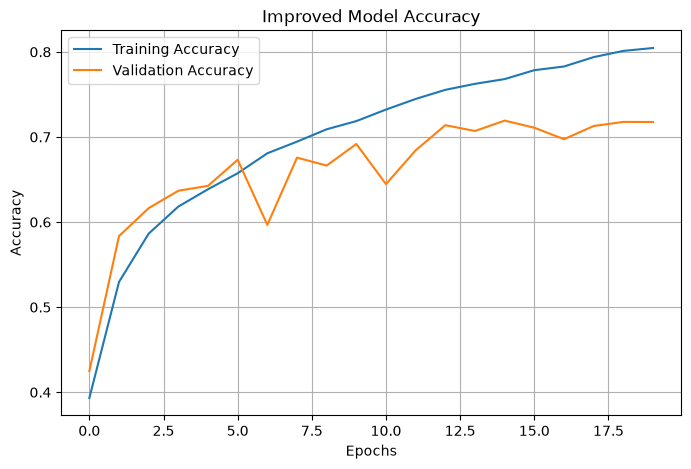

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history_improved.history['accuracy'], label='Training Accuracy')

plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Improved Model Accuracy')

plt.legend()
plt.grid(True)
plt.show()

## Loss Graph

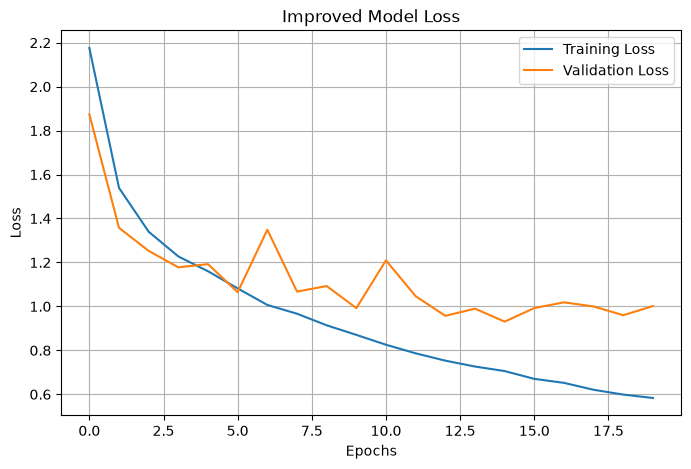

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Improved Model Loss')

plt.legend()
plt.grid(True)
plt.show()

# Comparing results of the Baseline Model and the Improved Model

In [24]:
baseline_accuracy = 0.6147

print("Model Comparison:")
print(f"Baseline Accuracy: {baseline_accuracy* 100:.2f}%")
print(f"Improved Model Accuracy: {improved_test_accuracy * 100:.2f}%")

accuracy_change = improved_test_accuracy - baseline_accuracy
print(f"Accuracy Change: {accuracy_change * 100:.2f}%")

Model Comparison:
Baseline Accuracy: 61.47%
Improved Model Accuracy: 72.65%
Accuracy Change: 11.18%


In [25]:
improved_model.save("improved_cnn.keras")
print("Improved model saved as 'improved_cnn.keras'")

Improved model saved as 'improved_cnn.keras'


# Improved Model predictions

In [26]:
improved_probabilities = improved_model.predict(x_test)

improved_predicted_labels = np.argmax(improved_probabilities, axis=1)

true_labels = np.argmax(y_test, axis=1)


285/285 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


# Clasification Report

In [27]:
print("\nClassification Report for Improved Model:")
print(classification_report(true_labels, improved_predicted_labels, target_names=final_classes, digits=4))


Classification Report for Improved Model:
              precision    recall  f1-score   support

  automobile     0.8386    0.9300    0.8819      1000
        bird     0.6888    0.7680    0.7262      1000
         cat     0.6060    0.6490    0.6268      1000
        deer     0.6851    0.8550    0.7607      1000
         dog     0.6819    0.7160    0.6985      1000
       horse     0.8092    0.8400    0.8243      1000
       truck     0.7981    0.8620    0.8288      1000
      cattle     0.5185    0.1400    0.2205       100
         fox     0.6500    0.2600    0.3714       100
        baby     0.5581    0.2400    0.3357       100
         boy     0.3710    0.2300    0.2840       100
        girl     0.3810    0.3200    0.3478       100
         man     0.3600    0.2700    0.3086       100
       woman     0.4167    0.2000    0.2703       100
      rabbit     0.4348    0.1000    0.1626       100
    squirrel     0.3830    0.1800    0.2449       100
     bicycle     0.8842    0.9160    0

# Confusion Matrix


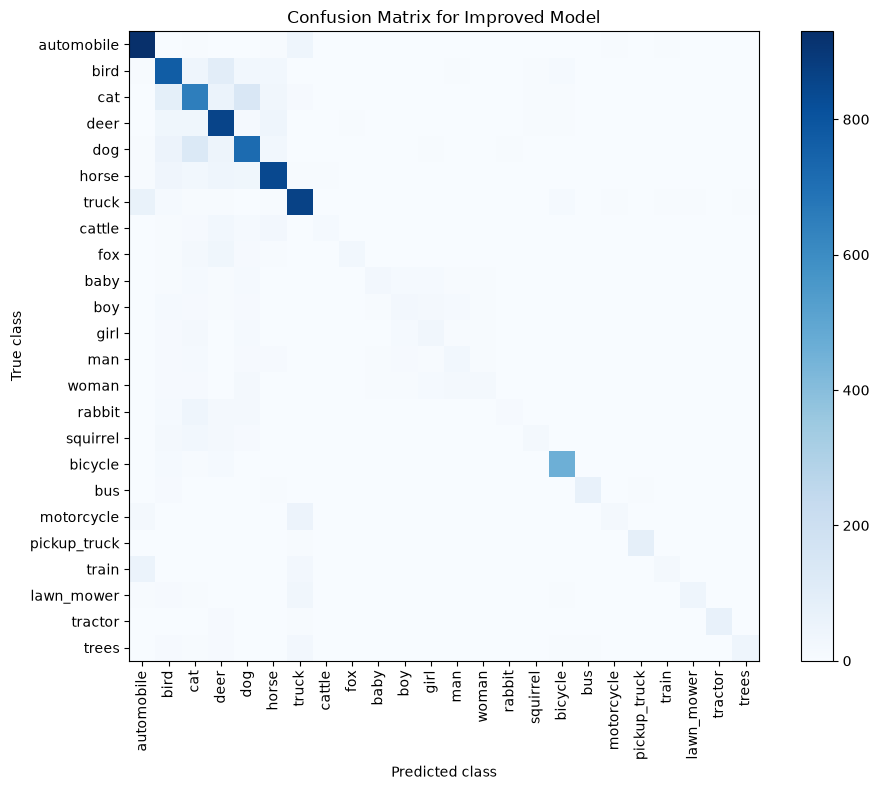

In [28]:
improved_cm = confusion_matrix(true_labels, improved_predicted_labels)

plt.figure(figsize=(10, 8))

plt.imshow(improved_cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Improved Model")
plt.colorbar()

tick_positions = np.arange(len(final_classes))

plt.xticks(tick_positions, final_classes, rotation=90)
plt.yticks(tick_positions, final_classes)

plt.xlabel('Predicted class')
plt.ylabel('True class')

plt.tight_layout()
plt.show()